TRAINING INSTABILE: LE SFIDE NEL CUORE DELLA GAN

- Mode Collapse: il fallimento della diversità generativa
- Vanisching Gradients: quando il critico uccide l'allievo
- Oscillazione e convergenza: analisi del sistema dinamico

Il training della GAN è più instabile rispetto a una rete neurale, il motivo è che non stai addestrando una sola funzione ma due reti che si inseguono continuamente.
Il Discriminatore D vuole distinguere reale dal falso
Il Generatore G vuole ingannare D
Quindi mentre D migliora, il problema che G deve risolvere cambia. E mentre G migliora, cambia il problema di D.
Questo rende il sistema diamico e potenzialmente oscillante. 

Il primo grande problema è lo SQUILIBRIO TRA GENERATORE E DISCRIMINATORE
Se D diventa troppo bravo troppo preso:
D(real)= 1
D(fake)= 0
D riconosce immediatamente tutte le immagini generate 
Per G questo è un problema, perchè il segnale di apprendimento può diventare poco informativo.
G produce immagini pessime -> D le riconosce tutte -> G riceve gradienti poco utili -> G migliora lentamente.
Al contrario:
Se D è troppo debole:
D(real)= 0.5 (circa)
D(fake)= 0.5 (circa)
D non riesce a fornire a G una guida utile
Quindi non si vuole in D perfetto subito e troppo velocemente.
Vuoi un D abbastanza bravo da guidare G, ma non così dominante da schiacciarlo.

Questo porta direttamente al secondo problema: i VANISCHING GRADIENTS
Momento in cui la comunicazione tra le reti si interrompe bruscamente.

G impara direttamente da D
Loss G -> Discriminator -> Generator
Se il Discriminator è troppo sicuro D(G(z))=0 tende a 0, l'apprendimento muore.
E' come uno studente che viene bocciato senza mai ricevere correzioni su ciò che ha sbagliato.
alcune formulazioni della loss possono produrre gradienti molto piccoli e quindi i pesi di G cambiano pochissimo
G praticamente smette di imparare
E' uno dei motivi per cui spesso di usa la loss non saturante

il colpevole è la Saturazione della Sigmoide
- Quando D classifica un campione sintetico con probabilità quasi zero, la funzione di perdita entra nella zona piatta della sigmoide
- In questa regione, la derivata è prossima a zero rendendo nullo l'aggioramento dei pesi di G tramite backpropagation
- Il generatore G non riceve più indicazioni su 'come' modificare i pixel per sembrare più reale.
- Il problema è aggravato se le distribuzioni p_data e p_g non hanno un supporto sovrapposto significativo.

Fortunatamente abbiamo strategia per riaccendere questo segnale.

Soluzioni Strategiche
Modificare l'obbiettivo di G per massimizzare la probabilità che D sbagli, invece di minimizzare la probabilità che D abbia ragione (Loss non saturante). Sembra la stessa cosa ma ci da gradienti più forti quando G sta sbagliando
Ridurre la capacità di D o aumentare il numero di parametri di G per mantenere la sfida equa (architetture bilanciate).
Aggiungere rumore alle immagini reali e finte per forzare le distriuzioni a sovrapporsi artificialmente e creare gradienti utili

La stabilità delle GAN dipende dalla capacità di D di fornire un gradiente che sia sia 'corretto' che 'abbastanza grande' da guidare G.
Abbiamo bisogno che D sia un critico costruttivo.

Il terzo problema è il MODE COLLAPSE

Si verifica quando il generatore G smette di esplorare l'intero spazio dei dati per concentrarsi su un unico sottoinsieme limitato
G potrebbe imparare che generare sempre un valore (es 3) le immagini possono essere anche realistiche ma poco varie.
La rete G imbroglia il sistema producendo sempre lo stesso campione perefetto, vanificando l'obbiettivo di modellare la distrinuzione globale
E' grave perchè una GAN deve imparare una distribuzione, non un singolo esempio plausibile

Se il generatore G scopre un punto debole nel discriminatore D e lo sfrutta producendo campioni quasi identici il modello ignora la varietà intrinseca del dataset originale (es. genera sempre il numero 3 di MNIST).
Matematicamente, la divergenza KL tra la distribuzioe reale e quella generata non viene minimizzata correttamente in tutte le sue componenti, ignora pertanto la varietà del mondo reale.
Non stiamo minimizzando la distanza tra due mondi, stiamo solo cercando la scorciatoia più veloce.
Il sistema rimane intrappolato in un minimo locale dello spazio dei parametri dove la varianza dell'output tende a zero.

Un aggiornamento troppo agressivo di G può portarlo a mappare tutto il rumore z in un'unica regione dello spazio dei dati.
Se D non riesce a penalizzare la mancanza di diversità, G non ha incentivi a generare campioni differenti.
Nelle griglie di monitoraggio, si osserva la comparsa di immagini ripetitive o pattern cromatici identici tra batch diversi.

Perchè G smette di esplorare?
Immagina un flsario che scopre che il poliziotto controlla solo la filigrana ma non il colore della banconota: il falsario stamperà solo banconote con la filigrana perfetta, ignorando tutto il resto (anche banconote viola o verdi).
Questo comportamento 'opportunistico' è intrinseco nella funzione obiettivo originale, che non penalizza esplicitamente la bassa entropia della distribuzione generata.



Un quarto problema è l'OSCILLAZIONE
Le curve di loss sembrano dei tracciati impazziti
Esempio
G impara a generare 7 convinventi
D impara a riconoscere quei 7
G cambia strategia, inizia a generare 3
D si adatta ai 3
G cambia ancora
Il sistema continua a inseguirsi senza convergere davvero.
Quindi la loss può avere un andamento: sale, scende, sale, scende, ecc

Un quinti problema è la SENSIBILITA' AGLI IPERPARAMETRI
Le GAN sono sensibili a: learning rate, beta1 di Adam, batch size, architettura, inizializzazione, normalizzazione, rapporto aggiornamenti D/G
Es.
lr=0.0002 e beta1=0.5 
sono valori molto comuin, spesso danno più stabilità rispetto ai default classici

Altro punto importante è IL NUMERO DI AGGIORNAMENTI DI D e G

A volte 1 aggiornamento di D corrisponde un aggiornamento di G
Ma non è inusuale avere tipi di aggiornamento diversi es:
5 aggiornamenti di D
1 aggiornamento di G
oppure il contrario, dipende dal tipo di GAN
L'obbiettivio è mantenere le due reti relativamente bilanciate.

Un sesto problema è IL PROBLEMA DELLA METRICA

Nelle reti classiche hai metriche molto chiare: accuracy, precision, recall, MAE e RMSE
Per una GAN la domanda è:
Quanto è buona un'immagine generata?
Vengono usate FID e Inception SCore ma spesso anche una valutazione visualie può far capire rapidamente.

Oscillazione e Convergenza
Un equilibrio instabile
A differenza del Supervised Learning, le GAN non minimizzano una funzione scalare statica. Stiamo cercando un equilibrio in un sistema dinamico tra due forze oposte.
Non ho un fondo della valle fisso.
Le curve di loss delle GAN sono spesso ingannevoli e non mostrano la classica discesa monotonoa

Dinamica Preda-Predatore
L'assenza di un minimo globale
I pesi di G e D possono orbitare indefinitamente attorno all'equilibrio senza mai fermarsi. 
Una diminuzione della loss di D spesso indica che G sta fallendo, non che il sistema sta migliorando. Significa che D ha vinto e G ha smesso di imparare
Il Nash Equilibrium è un punto di sella, non un minimo, rendendo l'ottimizzazione tramite SGD  intrinsecamente problematica.
Le oscillazioni si manifestano con la produzione di immagini che migliorano e peggiorano ciclicamente durante le epoche.
Le oscillazioni sono il segno che la lotta è ancora viva. Immagini che migliorano e poi peggiorano sono parte del processo di ricerca di questo equilibrio precario.

Come facciamo allora a capire se stiamo andando nella direzione giusta?
Dobbiamo cambiare il nostro modo di fare diagnostica

Monitoraggio Diagnostico
Non ci si può fidare ciecamente delle curve di loss
Loss costanti o oscillanti sono normali nelle GAN; curve che divergono indicano invece un fallimento catastrofico.
L'unico modo affidabile/reale per valutare il progresso è osservare la qualità visiva dei campioni generati a intervalli regolari (ispezione dei batch)
L'utilizzo di FID o Inception Score per quantificare oggettivamente la qualità oltre il semplice valore della loss.
Questi sono arbitri impariali che misurano la qualità della partita.

Verso la Stabilità
Interpretare il caos
Capire che la loos non è un indicatore di realismo è il primo passo per comprendere l'addestramento dei modelli avversari (GAN)
Loss apparentemente 'impazzite' possono in realtà produrre immagini di altissima qualità
Il realismo non è inversamente proporzionale alla loss.
Una loss di G alta potrebbe produrre immagini realistiche se D è diventato un critico estremamente sofisticato.

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.03MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 320kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.83MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.49MB/s]


Inizio addestramento su cpu...
Epoca [1/20] | Loss D: 0.0080 | Loss G: 5.9652
Epoca [2/20] | Loss D: 0.0233 | Loss G: 5.6100
Epoca [3/20] | Loss D: 0.1096 | Loss G: 2.8790
Epoca [4/20] | Loss D: 0.0252 | Loss G: 7.0482
Epoca [5/20] | Loss D: 0.0732 | Loss G: 3.8217
Epoca [6/20] | Loss D: 0.0106 | Loss G: 5.2757
Epoca [7/20] | Loss D: 0.0723 | Loss G: 3.6494
Epoca [8/20] | Loss D: 0.0879 | Loss G: 3.4587
Epoca [9/20] | Loss D: 0.0295 | Loss G: 5.1225
Epoca [10/20] | Loss D: 0.0238 | Loss G: 6.0761
Epoca [11/20] | Loss D: 0.0076 | Loss G: 6.2578
Epoca [12/20] | Loss D: 0.0651 | Loss G: 5.3250
Epoca [13/20] | Loss D: 0.0496 | Loss G: 4.5289
Epoca [14/20] | Loss D: 0.0823 | Loss G: 4.0770
Epoca [15/20] | Loss D: 0.0601 | Loss G: 4.1933
Epoca [16/20] | Loss D: 0.0149 | Loss G: 5.8514
Epoca [17/20] | Loss D: 0.0514 | Loss G: 4.8210
Epoca [18/20] | Loss D: 0.1178 | Loss G: 4.5007
Epoca [19/20] | Loss D: 0.0821 | Loss G: 3.3176
Epoca [20/20] | Loss D: 0.0259 | Loss G: 4.5758


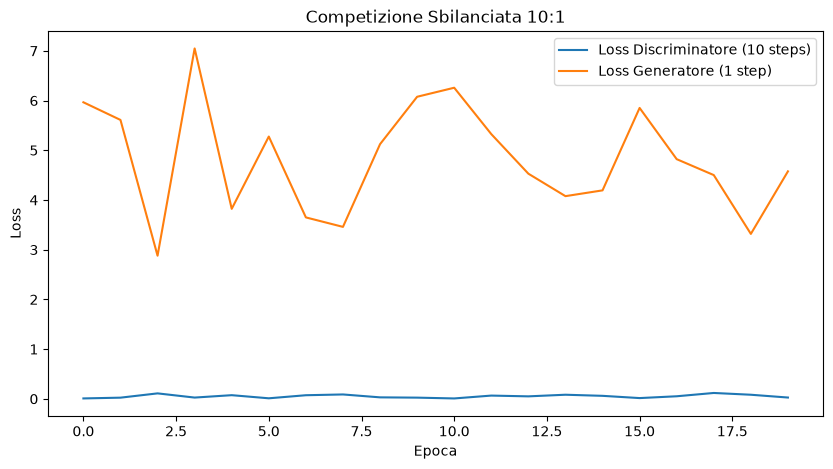

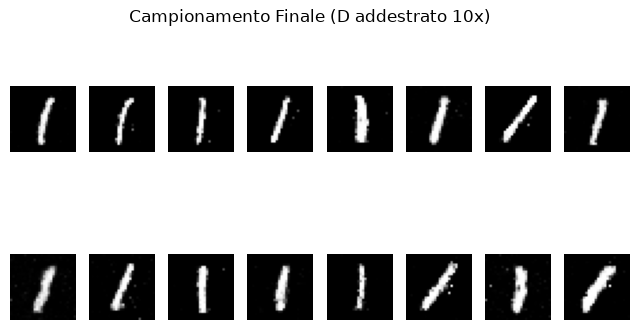

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# --- 1. CONFIGURAZIONE E IPERPARAMETRI ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
lr = 0.0002
batch_size = 64
latent_dim = 100
image_dim = 784  # 28x28
n_critic = 10    # La richiesta della traccia: 10 iterazioni di D per 1 di G
epochs = 20

# Trasformazioni: Normalizzazione [-1, 1] per matchare la Tanh del Generatore
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

#scarico immagini
dataset = datasets.MNIST(root="dataset/", train=True, transform=transform, download=True)
#il dataloader crea batch e ad ogni epoca rimescola
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# --- 2. ARCHITETTURE DENSE (MLP) ---
class Generator(nn.Module):
    def __init__(self): #costruisce la rete
        super().__init__() #inizializza nn.module
        self.gen = nn.Sequential(  #sequential significa che l'output di un layer è input del successivo layer
            nn.Linear(latent_dim, 256), #100 (latent_dim) valori restituiscono 256 valori
            nn.LeakyReLU(0.2), # x>0 -> x   x<=0 -> 0.2*x
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, image_dim), #output Generator
            nn.Tanh()  #la tanh porta ogni valore tra -1 e 1
        )
    def forward(self, x):
        return self.gen(x)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.disc = nn.Sequential(
            nn.Linear(image_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1), #output 1 valore, risponde alla domanda: Quanto penso che questa immagine sia vera?
            nn.Sigmoid() #tra 0 e 1 per interpretare come probabilità
        )
    def forward(self, x):
        return self.disc(x)

# Inizializzazione modelli e ottimizzatori
gen = Generator().to(device) #creazione modello G
disc = Discriminator().to(device) #creazione modello D
opt_gen = optim.Adam(gen.parameters(), lr=lr, betas=(0.5, 0.999)) #optimizer per modificare parametri di gen
opt_disc = optim.Adam(disc.parameters(), lr=lr, betas=(0.5, 0.999)) #optimizer per modificare parametri di disc
criterion = nn.BCELoss() #funzione di loss

# --- 3. CUSTOM TRAINING LOOP (10:1 Ratio) ---
loss_history_G = [] #tiene traccia dello storico di G
loss_history_D = [] #tiene traccia dello storico di D

print(f"Inizio addestramento su {device}...")

for epoch in range(epochs): #per ogni epoca
    #il dataloader aveva diviso in batch (batch, immagine, label)
    for batch_idx, (real, _) in enumerate(dataloader): #per ogni batch
        real = real.view(-1, 784).to(device)
        curr_b_size = real.shape[0]

        # --- STEP 1: ADDESTRAMENTO INTENSIVO DEL DISCRIMINATORE (n_critic volte) ---
        # In questo loop D diventa molto esperto prima che G possa muovere un passo
        for _ in range(n_critic): #eseguo 10 aggiornamento consecutivi di D
            noise = torch.randn(curr_b_size, latent_dim).to(device) # creazione rumore
            fake = gen(noise) #generazione immagine falsa (64 immagini false)
            
            # Perdita sui reali
            disc_real = disc(real).view(-1) #D valuta immagini vere
            loss_disc_real = criterion(disc_real, torch.ones_like(disc_real)) #vettore di 1 (immagini vere)
            
            # Perdita sui fake (.detach() è fondamentale per non toccare G)
            disc_fake = disc(fake.detach()).view(-1) #D valuta immagini false (.detach G non impare, resta immobile)
            loss_disc_fake = criterion(disc_fake, torch.zeros_like(disc_fake))
            
            loss_disc = (loss_disc_real + loss_disc_fake) / 2
            
            disc.zero_grad()
            loss_disc.backward()
            opt_disc.step()

        # --- STEP 2: ADDESTRAMENTO DEL GENERATORE (1 volta) ---
        # G prova a rispondere al Discriminatore ormai molto "severo"
        noise = torch.randn(curr_b_size, latent_dim).to(device)
        fake = gen(noise)
        output = disc(fake).view(-1)
        
        # Trucco non-saturante: G vuole che D dica "Vero" (1)
        loss_gen = criterion(output, torch.ones_like(output))
        
        gen.zero_grad()
        loss_gen.backward()
        opt_gen.step()

    # Logging
    loss_history_D.append(loss_disc.item())
    loss_history_G.append(loss_gen.item())
    print(f"Epoca [{epoch+1}/{epochs}] | Loss D: {loss_disc:.4f} | Loss G: {loss_gen:.4f}")

# --- 4. VISUALIZZAZIONE RISULTATI ---
# Grafico delle Loss
plt.figure(figsize=(10, 5))
plt.plot(loss_history_D, label="Loss Discriminatore (10 steps)")
plt.plot(loss_history_G, label="Loss Generatore (1 step)")
plt.title("Competizione Sbilanciata 10:1")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Immagini generate
with torch.no_grad():
    sample_noise = torch.randn(16, latent_dim).to(device)
    samples = gen(sample_noise).cpu().view(-1, 28, 28)
    plt.figure(figsize=(8, 4))
    for i in range(16):
        plt.subplot(2, 8, i+1)
        plt.imshow(samples[i], cmap="gray")
        plt.axis("off")
    plt.suptitle("Campionamento Finale (D addestrato 10x)")
    plt.show()